# 静态面板门槛模型：Stata 实操

&emsp;

> **作者：** 连玉君 (中山大学)    
> **邮箱：** <arlionn@163.com> 

Update: `2025.1.26`

&emsp;

**Keywords**: 面板门槛模型, Hansen, xthreg, 非线性关系, Bootstrap, 门槛效应检验

&emsp;

In [11]:
*-settings

global root "`c(sysdir_personal)'PX_B_2026a/B1_hetPanel"
global data "$root/data"

set scheme tufte

cd $data 

*-install packages
cap which xthreg 
if _rc{
    net install st0373.pkg, replace from(http://www.stata-journal.com/software/sj15-1)
}

D:\stata\personal\PX_B_2026a\B1_hetPanel\data


## Stata 实操：xthreg 命令

### 命令安装

Wang (2015) 编写的 `xthreg` 命令实现了 Hansen (1999) 的面板门槛模型：

> Wang, Q. (2015). Fixed-Effect Panel Threshold Model using Stata. *The Stata Journal*, 15(1), 121–134. [Link](https://doi.org/10.1177/1536867X1501500108), [PDF](https://journals.sagepub.com/doi/pdf/10.1177/1536867X1501500108), [Google Scholar](https://scholar.google.com/scholar?q=Fixed-Effect+Panel+Threshold+Model+using+Stata).

### 命令语法

```stata
help xthreg
```

```stata

xthreg depvar [indepvars] [if] [in] , ///
    rx(varname) qx(varname) ///
    [thnum(#) trim(#) grid(#) bs(#) nolog]
```

**主要选项说明：**

- `rx(varname)`：指定区间依赖变量（regime-dependent variables），即系数会随门槛变化的变量
- `qx(varname)`：指定门槛变量（threshold variable）
- `thnum(#)`：指定门槛个数，默认为 1
- `trim(#)`：门槛值搜索时的修剪百分比，默认为 0.15（即保留 15%-85% 分位数之间的值）
- `grid(#)`：网格搜索点数，默认为 400
- `bs(#)`：Bootstrap 重复次数，用于门槛效应检验
- `nolog`：不显示迭代过程

**重要说明：**

1. 在使用 `xthreg` 之前，必须先用 `xtset` 声明面板数据结构
2. `rx()` 选项中指定的变量的系数会在不同区间（regime）中不同
3. `indepvars` 中的变量系数在所有区间中保持不变
4. Bootstrap 检验（`bs()` 选项）非常耗时，建议在初步分析时先不使用

## 模拟数据实例

为了更好地理解面板门槛模型的特性，我们首先使用模拟数据进行演示。这可以帮助我们：

1. 直观理解门槛效应的含义
2. 验证估计方法的有效性
3. 了解不同估计方法的优劣

### 单一门槛模型的模拟

我们生成一个简单的门槛模型数据：

$$
y = \begin{cases}
1 + 2x + \varepsilon & \text{若 } t \le 50 \\
1 - 2x + \varepsilon & \text{若 } t > 50
\end{cases}
$$

其中 $\varepsilon \sim N(0,1)$，$x \sim N(0,9)$。

In [12]:
* 生成模拟数据
clear
set obs 100
set seed 123456

gen e = rnormal()          // 误差项 e ~ N(0,1)
gen x = rnormal(0, 3)      // 解释变量 x ~ N(0, 9)
gen t = _n                 // 时间变量 t = 1,2,...,100

* 生成因变量 y（在 t=50 处存在门槛）
gen y = .
tsset t
replace y = 1 + 2*x + e
replace y = 1 - 2*x + e if t > 50

* 保存数据
save "xthreg_sim1.dta", replace

Number of observations (_N) was 0, now 100.
(100 missing values generated)

Time variable: t, 1 to 100
        Delta: 1 unit
(100 real changes made)
(50 real changes made)
file xthreg_sim1.dta saved


### 初步探索性分析

对于一个不知道上述数据生成过程 (DGP) 的研究者而言，由于样本中只有三个变量：$y$、$x$ 和 $t$。为了探究变量之间的关系，他可能会先绘制 $y$ 和 $t$ 以及 $x$ 之间的散点图，以期初步分析变量之间的关系


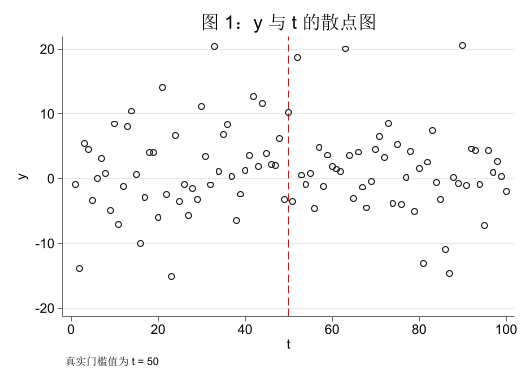

In [13]:
* 绘制散点图
use "xthreg_sim1.dta", clear 
scatter y t, ///
    xline(50, lp(dash) lcolor(red)) ///
    title("图 1：y 与 t 的散点图") ///
    note("真实门槛值为 t = 50")

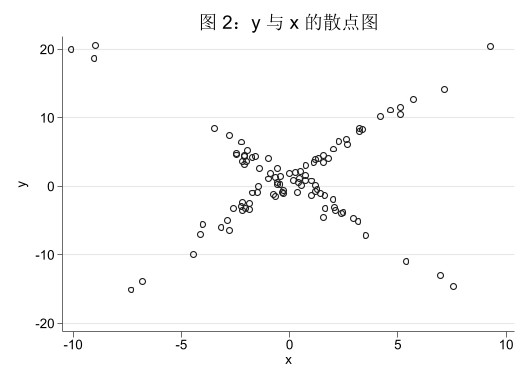

In [14]:

scatter y x, title("图 2：y 与 x 的散点图")

从上面的图形中可以看出，$y$ 与 $t$ 之间似乎不存在明显的线性关系，而 $y$ 与 $x$ 之间则呈现出某种非线性关系。有如下两点说明：

- 从 DGP 来看，$y$ 与 $t$ 之间确实没有直接关系。$y$ 与 $x$ 之间的关系则受到门槛变量 $t$ 的影响，在 $t \le 50$ 时，$y$ 随 $x$ 增加而增加；而在 $t > 50$ 时，$y$ 随 $x$ 增加而减少。
- 很多读者在执行 `twoway scatter y x` 之前，预期看到的图形是一个 `V 字形`，而不是上图中呈现的 `X 字形`。这是因为，调节 $y$ 和 $x$ 之间的关系的变量是 $t$，而不是 $x$ 本身。这也是此类问题的复杂之处所在。因此，在使用门槛模型进行分析之前，要对问题的背景有充分的理解，并从理论上确定可能的门槛变量。

### 如何识别门槛值？

假如我们只知道 $t$ 是门槛变量，它会影响 $y$ 和 $x$ 之间的关系，但并不清楚具体的门槛值是多少。此时，我们可以借助 Chow 检验的思想来初步识别门槛值。

基本思路是「让数据说话」：我们可以在 $t$ 的取值范围内，尝试不同的切分点，将样本划分为两组，然后引入交叉项来刻画结构变化，进而通过比较模型的拟合效果 (如 RSS) 来识别最佳切分点。

在正式开始搜索之前，先举个简单的例子。假设我们分析后认为门槛值可能是 $t=40$，我们可以先进行三次回归，分别对应「全样本回归」、「左侧区间回归 ($t \le 40$)」和「右侧区间回归 ($t > 40$)」，以便后续比较。具体代码如下：

In [15]:
use "xthreg_sim1.dta", clear 

* (1) 全样本回归 - 忽略门槛效应
qui reg y x
est store full

* (2) 左侧区间回归 (t <= 40)
qui reg y x if t <= 40
est store left

* (3) 右侧区间回归 (t > 40)
qui reg y x if t > 40
est store right

* 比较回归结果
esttab full left right, mtitle("全样本" "t<=40" "t>40") ///
    s(N r2 rss) b(%6.3f) se(%6.3f) ///
    star(* 0.1 ** 0.05 *** 0.01) 
   


------------------------------------------------------------
                      (1)             (2)             (3)   
                   全样本           t<=40            t>40   
------------------------------------------------------------
x                   0.053           2.065***       -1.418***
                  (0.207)         (0.047)         (0.187)   

_cons               1.376**         1.067***        2.039***
                  (0.684)         (0.158)         (0.610)   
------------------------------------------------------------
N                 100.000          40.000          60.000   
r2                  0.001           0.981           0.496   
rss              4587.379          38.029        1292.581   
------------------------------------------------------------
Standard errors in parentheses
* p<0.1, ** p<0.05, *** p<0.01


可以看出，使用全样本进行回归时，拟合效果非常差，`r2` 仅为 0.001，说明模型几乎没有解释力。相比之下，分区间回归的拟合效果明显提升，`r2` 分别为 0.981 (左侧) 和 0.496 (右侧)。这意味着，存在结构变化，且 $t=40$ 是一个有助于改善模型拟合的门槛值。

我们也注意到，上述估计结果中 `rss` (残差平方和) 也有类似的表现，而且其数值变化非常灵敏。因此，在后续的门槛值搜索过程中，我们可以重点关注 `rss` 指标。之所以不使用 `r2`，是因为其取值基本上介于 0 和 1 之间，变化范围有限，在密集搜素过程中灵敏度不足。


### 进一步搜索门槛值

沿着上述分析思路，我们可以在 $t$ 的取值范围内，尝试不同的切分点 (如从 10 到 90，每隔 1 个单位取一个点)，然后计算每个切分点对应的 `rss`，最终选择 `rss` 最小的切分点作为门槛值。

为了将所有观察值都纳入分析，我们在模型中引入虚拟变量 `d` (用以区分不同区间)，以及 `d` 与 $x$ 的交叉项，从而构建如下模型 (本例中截距项没有发生变化，故省去 `d`)：

$$
y = \beta_0 + \beta_1 x + \beta_2 (x \times d) + \varepsilon
$$

其中 $d = I(t > \gamma)$ 是指示变量。

In [16]:
use "xthreg_sim1.dta", clear 

* 如果不知道断点，尝试不同的假设断点
dropvars d* xd*
qui{
    gen d = .
    gen xd = .
    
    replace d = (t > 10)
    replace xd = x * d
    reg y x xd
    est store t10

    replace d = (t > 30)
    replace xd = x * d
    reg y x xd
    est store t30

    replace d = (t > 50)
    replace xd = x * d
    reg y x xd
    est store t50    
    
    replace d = (t > 60)
    replace xd = x * d
    reg y x xd
    est store t60
}

Unable to drop d* xd*


In [9]:
* 比较不同断点假设下的结果
esttab full t10 t30 t50 t60, ///
    mtitle("全样本" "t=10" "t=30" "t=50" "t=60") ///
    s(r2 rss) b(2) not nogap compress star(* 0.05)


-----------------------------------------------------------------
                 (1)        (2)        (3)        (4)        (5) 
              全样本       t=10       t=30       t=50       t=60 
-----------------------------------------------------------------
x               0.05       2.19*      2.10*      2.07*      1.41*
xd                        -2.31*     -2.96*     -4.05*     -3.42*
_cons           1.38*      1.54*      1.92*      0.95*      1.26*
-----------------------------------------------------------------
r2              0.00       0.09       0.44       0.98       0.67 
rss          4587.38    4197.44    2557.83     107.69    1520.84 
-----------------------------------------------------------------
* p<0.05


### 网格搜索结构突变点

虚拟变量法的结果表明，在真实断点 $t=50$ 处，残差平方和最小，R方和对数似然最大。这启发我们可以通过**网格搜索**的方法来找到最优断点。

(100 missing values generated)

     +----------------+
     |       rss    t |
     |----------------|
  1. | 107.68875   50 |
  2. | 183.23571   51 |
  3. | 404.06021   49 |
  4. | 468.19032   48 |
  5. | 564.77645   47 |
     +----------------+


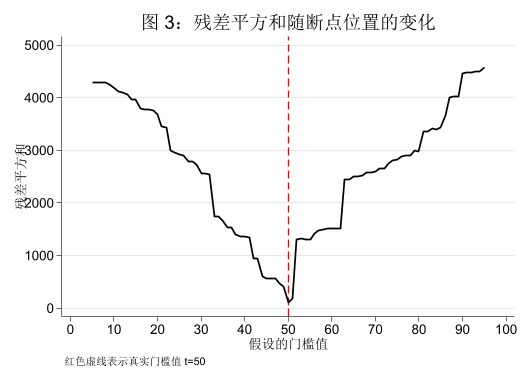

In [17]:
use "xthreg_sim1.dta", clear 

* 网格搜索：在 t = 5 到 t = 95 之间搜索最优断点
gen rss = .
forvalues i = 5/95 {
    gen di = (t > `i')
    gen xdi = x * di
    qui reg y x xdi
    qui replace rss = e(rss) in `i'
    drop di xdi
}

* 查看 RSS 最小的前 5 个时点
sort rss
list rss t in 1/5

* 绘制 RSS 随时间变化的曲线
line rss t, ///
    lw(*1.5) xlabel(0(10)100) sort ///
    xline(50, lp(dash) lw(*1.2) lcolor(red)) ///
    title("图 3：残差平方和随断点位置的变化") ///
    note("红色虚线表示真实门槛值 t=50") ///
    ytitle("残差平方和") ///
    xtitle("假设的门槛值")

### 模拟数据分析小结

通过模拟数据分析，我们得到以下重要结论：

1. **全样本回归严重偏误**：忽略门槛效应会导致 $x$ 的系数接近 0，完全无法反映真实关系

2. **错误断点导致偏差**：在 $t \ne 50$ 处进行分组回归，模型的参数估计偏差很大，意味着传统的估计方法可能存在严重偏误

3. **网格搜索有效**：在 $t=50$ 处，RSS 最小，这对建模有重要启示

4. **大样本费时问题**：对于大样本而言，逐点搜索仍然非常耗时

**Hansen (1999, p.349) 的建议：**

- 只搜索门槛变量 $q_{it}$ 中的非重复值
- 对这些非重复值排序，在 [1%, 99%] 区间内搜索
- 如果需要搜索的格点仍然很多，可以在上述区间内仅搜索特定的百分位数

## 案例 1：融资约束与投资-现金流敏感性 (Hansen, 1999)

本节演示 Hansen (1999) 在提出面板门槛模型的经典论文中展示的一个实证应用。

中，我们将使用一个实际的面板数据来演示 `xthreg` 命令的使用。我们使用 Hansen (1999) 原文中的数据，研究投资与融资约束的关系。

> Hansen, B. E. (1999). Threshold effects in non-dynamic panels: Estimation, testing, and inference. *Journal of Econometrics*, 93(2), 345–368. [Link](https://doi.org/10.1016/S0304-4076%2899%2900025-1), [PDF](http://sci-hub.ren/10.1016/S0304-4076%2899%2900025-1), [Google](<https://scholar.google.com/scholar?q=Threshold effects in non-dynamic panels: Estimation, testing, and inference>).

### 问题背景：为什么需要“阈值”视角

在经典的完美资本市场框架下，企业的投资支出应主要由投资机会决定。这意味着若我们估计如下投资模型，$cflow$ (内部现金流) 的系数应不显著：

$$I_{it} = \alpha_i + \beta Q_{i,t-1} + \gamma cflow_{i,t-1} + e_{it}$$

然而，以 Fazzari et al. (1988, 简称 FHP) 为代表的一系列实证研究发现，$cflow$ 对投资支出的影响显著且正向，这一现象被称为 “投资-现金流敏感性” (investment-cash flow sensitivity)。他们用「融资约束假说」来解释这一现象：融资约束导致企业的外部融资成本高于内部融资成本，从而使企业的投资决策受到内部现金流的限制。

> Fazzari, S. M., Hubbard, R. G., & Petersen, B. C. (1988). Financing Constraints and Corporate Investment. *Brookings Papers on Economic Activity*, 1988(1), 141–206. [Link](https://doi.org/10.2307/2534426), [PDF](http://sci-hub.ren/10.2307/2534426), [Google](<https://scholar.google.com/scholar?q=Financing Constraints and Corporate Investment>). 

Fazzari et al. (1988) 的检验策略非常直白：他们将企业按 “股利支付占收入之比 (dividend-to-income ratio)” 分组，将持续支付高股利的企业视为「非融资约束组 (NFC)」，将那些长期不支付股利的企业视为「融资约束组 (FC)」，进而分别估计两组的「投资-现金流敏感系数 ($\hat{\gamma}$)」。基本的理论预期是 $\hat{\gamma}_{FC} > \hat{\gamma}_{NFC}$。

这一检验策略的好处在于，即使存在衡量偏误或遗漏偏误等问题，但只要假设 FC 组和 NFC 组的偏误程度相近，那么两组系数的差异仍然可以反映融资约束对投资行为的影响。后续大量研究都延续了这一检验思路。 

Hansen (1999) 指出 FHP 方案存在两个潜在问题：

* 他们将股利占比当作外生阈值变量 (用以衡量融资约束程度)，但理论上股利是企业决策变量 (潜在内生)，可能导致阈值分组偏误。
* 阈值水平 (如 0.1 和 0.2) 由研究者任意指定，而不是由样本估计得到的。

对于第一个问题，Hansen (1999) 选用「公司负债率 ($D_{it}$)」作为阈值变量。他的主要贡献在在于使用面板门槛模型来解决第二个问题，通过搜索让数据自己决定阈值水平。



### 数据与门槛变量选择

Hansen (1999) 的样本包含 565 家美国制造业企业，时间跨度为 1973-1987 年，共计 15 年的面板数据。他认为 “长期负债/资产比 ($D$)” 具有一定的外生性，更适用作为「融资约束程度」的衡量指标：$D$ 越大则融资约束越严重。这对应面板门槛模型中的门槛变量。模型设定如下：

$$
\begin{align}
I_{it} =\ & \mu_i
+\theta_1 Q_{i,t-1}+\theta_2 Q_{i,t-1}^2+\theta_3 Q_{i,t-1}^3
+\theta_4 D_{i,t-1}+\theta_5 Q_{i,t-1}D_{i,t-1} \\
& + \beta_1 CF_{i,t-1} I(D_{i,t-1}\le \gamma_1) \\
& + \beta_2 CF_{i,t-1} I(\gamma_1<D_{i,t-1}\le \gamma_2) \\
& + \beta_3 CF_{i,t-1} I(\gamma_2<D_{i,t-1})
+e_{it}.
\end{align}
$$

变量记号在文中定义为 ：

* $I_{it}$：investment-to-capital ratio；
* $Q_{it}$：total market value / assets；
* $CF_{it}$：cash flow / assets；
* $D_{it}$：long-term debt / assets。

融融资约束假说成立，则可以预期 $\beta_1 < \beta_2 < \beta_3$，或者至少 $\beta_1 < \beta_3$。


### Stata 实操

In [34]:
*-download data, get 'hansen1999.dta'
net get st0373.pkg, replace from(http://www.stata-journal.com/software/sj15-1)

checking st0373 consistency and verifying not already installed...
all files already exist and are up to date.


In [18]:
* 加载数据
  use "hansen1999.dta", clear

* 声明面板数据结构
  xtset id year

* 查看数据结构
  describe i q c d

(The Value and Performance of U.S.Corporations (B.H.Hall & R.E.Hall, 1993))

Panel variable: id (strongly balanced)
 Time variable: year, 1974 to 1987
         Delta: 1 year

Variable      Storage   Display    Value
    name         type    format    label      Variable label
-------------------------------------------------------------------------------
i               double  %10.0g                investments/assets
q               double  %10.0g                Tobin Q
c               double  %10.0g                crash flow/asset
d               double  %10.0g                debt/assets


**主要变量说明：**

- `i`：投资率 (investment rate)，定义为投资支出与期初资本存量的比值
- `q1`：托宾 Q 值 (Tobin's Q)，衡量企业的市场价值与重置成本之比
- `c1`：现金流 (cash flow)，标准化后的值
- `d1`：债务权益比 (debt-to-equity ratio)，作为门槛变量
- `id`：企业标识
- `year`：年份

In [19]:
*-Table 1: Summary statistics
  fsum i q1 c1 d1, s(mean sd min p25 p50 p75 max) ///
          format(%8.3f) 


 Variable |       N    Mean      SD     P25  Median     P75     Min     Max                                                                                        
----------+----------------------------------------------------------------
        i |    7910   0.089   0.062   0.049   0.076   0.113   0.001   1.655  
       q1 |    7910   1.195   2.862   0.371   0.675   1.308   0.021 111.796  
       c1 |    7910   0.252   0.310   0.124   0.216   0.321  -0.937   8.707  
       d1 |    7910   0.234   0.218   0.089   0.206   0.320   0.000   4.673  


In [37]:
*-Estimating
 
 *-单一门槛模型 (可选)
 xthreg i q1 q2 q3 d1 qd1, ///
        rx(c1) qx(d1) ///
        thnum(1) /// 
        trim(0.05) ///
        grid(400) ///
        bs(300)
 

Estimating  the  threshold  parameters:   1st ......  Done
Boostrap for single threshold
.................................................. +   50
.................................................. +  100
.................................................. +  150
.................................................. +  200
.................................................. +  250
.................................................. +  300

Threshold estimator (level = 95):
-----------------------------------------------------
     model |    Threshold         Lower         Upper
-----------+-----------------------------------------
      Th-1 |       0.0158        0.0141        0.0169
-----------------------------------------------------

Threshold effect test (bootstrap = 300):
-------------------------------------------------------------------------------
 Threshold |       RSS        MSE      Fstat    Prob   Crit10    Crit5    Crit1
-----------+--------------------------------------------

实际分析中，我们预先并不知晓数据生成过程，自然也就不知道到底有几个门槛值。这就需要通过假设检验来确定门槛的个数。这本质上属于模型设定的过程，因为一旦明确了门槛的个数，就很容易通过网格搜索确定门槛值。随后的分析无非就是使用 OLS 估计包含一个或多个交互项的线性模型而已。

虽然从理论上来讲可能存在多个门槛值，但多数应用中以一个或两个门槛值为主。因此，我们从较为一般化的三重门槛模型开始分析。

由于当前的主要目的是采用 Bootstrap 方法检验门槛的个数，在如下命令中使用了 `noreg` 选项来屏蔽冗长的回归输出；同时，添加了 `nobslog` 选项以屏蔽 Bootstrap 过程中在屏幕上打印小黑点。

In [ ]:
*-估计三重门槛模型, 检验门槛个数
 xthreg i q1 q2 q3 d1 qd1, rx(c1) qx(d1) thnum(3) /// 
        trim(0.01 0.01 0.05) grid(400) bs(300 300 300) ///
        noreg nobslog 

Estimating  the  threshold  parameters:   1st ......  2nd ......  3rd ......  D
> one
Boostrapping for threshold effect test:   1st ......  2nd ......  3rd ......  D
> one

Threshold estimator (level = 95):
-----------------------------------------------------
     model |    Threshold         Lower         Upper
-----------+-----------------------------------------
      Th-1 |       0.0154        0.0141        0.0167
     Th-21 |       0.0154        0.0141        0.0167
     Th-22 |       0.5418        0.5268        0.5473
      Th-3 |       0.4778        0.4755        0.4823
-----------------------------------------------------

Threshold effect test (bootstrap = 300 300 300):
-------------------------------------------------------------------------------
 Threshold |       RSS        MSE      Fstat    Prob   Crit10    Crit5    Crit1
-----------+-------------------------------------------------------------------
    Single |   17.7818     0.0023      35.20  0.0000  11.6018  14.1678 

#### 门槛值的解释

解释 `Th-1`，`Th-21`，`Th-22` 和 `Th-3` 的含义：

- 第一轮搜索：假设只有一个门槛，此时估计的是单一门槛模型，得到的门槛估计值为 `Th-1`
- 第二轮搜索：假设有两个门槛，此时估计的是双重门槛模型，得到的两个门槛估计值分别为 `Th-21` 和 `Th-22`。说明如下：
  - 有些情况下，这两个门槛值非常接近，本质上等价于单一门槛模型。此时，可以将 `trim()` 选项中的值调大一些，强制要求每个区间内有足够的样本量。
  - `Th-21` 和 `Th-22` 不必然按大小排序。因为 Hansen 是基于参数更新法获得门槛估计值的，即先估计第一个门槛 ($\hat{\gamma}_{21}$)，然后将其视为固定值 (基于 $\hat{\gamma}_{21}$ 生成虚拟变量和交乘项，并作为控制变量加入模型)，继续采用单一门槛模型的估计方法搜索第二个门槛 $\hat{\gamma}_{22}$。
- 第三轮搜索：假设有三个门槛，此时估计的是三重门槛模型，得到的门槛估计值为 `Th-3`。估计方法为：固定第二轮搜索得到的两个门槛值，继续采用单一门槛模型的估计方法搜索第三个门槛 $\hat{\gamma}_{3}$。

就本例而言，$\hat{\gamma}_{21}$ 和 $\hat{\gamma}_{22}$ 分别为 $0.0154$ 和 $0.5418$，具有明显的区分度。注意，此处的门槛变量为 `d1` (负债率)，其样本均值为 0.234，最小值为 0，最大值为 4.673。

#### 门槛效应检验

「Threshold effect test」是指对门槛效应的显著性进行检验，这是我们确定模型设定形式的重要依据。我们重点关注 F 统计量(`Fstat`)及其对应的 p 值(`Prob`)。结合输出结果，可以按“逐步检验”的思路解读：

* **Single threshold**: `Fstat = 35.20`，`Prob = 0.0000`，且 `Fstat` 明显大于 `Crit10/Crit5/Crit1`。因此，我们可以**拒绝**“无门槛效应(线性模型)”的原假设，说明数据支持**至少存在 1 个门槛**。
* **Double threshold**: `Fstat = 24.97`，`Prob = 0.0100`，且 `Fstat` 大于 `Crit10` 和 `Crit5`(但略高于或接近 `Crit1` 的判断不必过度强调)。因此，我们同样可以在 5% 乃至 10% 的显著性水平下**拒绝**“只有 1 个门槛”的原假设，说明在单门槛的基础上，模型进一步支持**存在 2 个门槛**。
* **Triple threshold**: `Fstat = 6.20`，`Prob = 0.5700`，且 `Fstat` 小于所有临界值(`Crit10/Crit5/Crit1`)。因此，我们**无法拒绝**“只有 2 个门槛”的原假设，数据并不支持再加入第 3 个门槛。

综合以上三步检验，一个自然的结论是：该样本更支持 **Double threshold model(双门槛, 三个 regime)**。换言之，阈值变量将样本划分为三个区间，在不同区间内，核心解释变量(通常是 `rx()` 中指定的变量)的边际效应存在显著差异。

需要说明的是，这里的结果是基于 300 次 Bootstrap 重复得到的。实际应用中，建议使用更多的重复次数(如 1000 次或更多)，以获得更稳定的结果。

#### 估计双重门槛模型

既然上述检验结果支持双重门槛模型，我们可以进一步估计该模型的参数。具体命令如下：

In [46]:
		
 *-确认为双重门槛模型, 估计之
   xthreg i q1 q2 q3 d1 qd1, rx(c1) qx(d1) thnum(2) /// 
        trim(0.05 0.05) grid(400) bs(500 500) nobslog
   
   * trim(0.05)  调高了
   * bs(500 500)  增加了 bootstrap 次数

Estimating  the  threshold  parameters:   1st ......  2nd ......  Done
Boostrapping for threshold effect test:   1st ......  2nd ......  Done

Threshold estimator (level = 95):
-----------------------------------------------------
     model |    Threshold         Lower         Upper
-----------+-----------------------------------------
      Th-1 |       0.0158        0.0141        0.0169
     Th-21 |       0.0158        0.0141        0.0169
     Th-22 |       0.1396        0.1080        0.1406
-----------------------------------------------------

Threshold effect test (bootstrap = 500 500):
-------------------------------------------------------------------------------
 Threshold |       RSS        MSE      Fstat    Prob   Crit10    Crit5    Crit1
-----------+-------------------------------------------------------------------
    Single |   17.7855     0.0023      33.56  0.0000  10.7373  13.7479  19.4979
    Double |   17.7686     0.0023       7.53  0.2340  10.1193  13.1697  18.9219

In [48]:
esttab, nogap


----------------------------
                      (1)   
                        i   
----------------------------
q1                 0.0103***
                  (11.54)   
q2                -0.0199***
                  (-7.76)   
q3                0.00106***
                   (5.42)   
d1                -0.0207***
                  (-4.77)   
qd1              0.000970   
                   (0.68)   
0._cat#c.c1        0.0577***
                  (10.71)   
1._cat#c.c1        0.0937***
                  (15.44)   
2._cat#c.c1        0.0794***
                  (13.67)   
_cons              0.0627***
                  (36.98)   
----------------------------
N                    7910   
----------------------------
t statistics in parentheses
* p<0.05, ** p<0.01, *** p<0.001


#### 图示门槛值及检验结果


e(Thrss)[3,5]
       Threshold        RSS   Location      Lower      Upper
 Th-1     .01582  17.785507         19     .01409     .01688
Th-21     .01582  17.768564         19     .01409     .01688
Th-22     .13956  17.768564         87     .10801     .14059


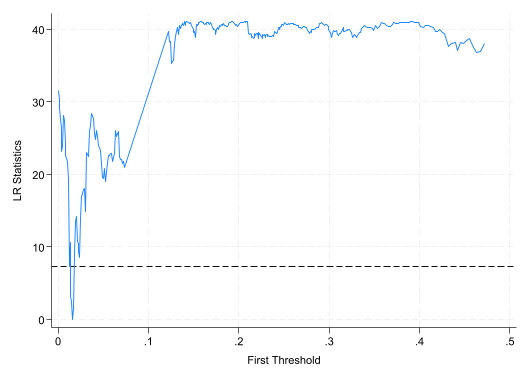

In [ ]:
*-提取门槛值, 后续回归分析中会使用
  //ereturn list
    mat list e(Thrss)
    mat s = e(Thrss)  //记录门槛值的矩阵
    global q1 = s[2,1]      //保存估计出的第一个门槛值,以备后用 
    global q2 = s[3,1]      //保存第二个门槛值 		
		
*-Graphing
   
  *-第一个门槛值的 LR 图形
   cap graph drop LR21
   _matplot e(LR21), columns(1 2) yline(7.35, lpattern(dash))  ///
     connect(direct) msize(small) mlabp(0) mlabs(zero)         ///
     ytitle("LR Statistics") xtitle("First Threshold")         ///
	 recast(line) name(LR21) 
   graph export "$Out/Hansen_Fig01.png", replace //保存图片
   


(file /Hansen_Fig02.png not found)
file /Hansen_Fig02.png written in PNG format


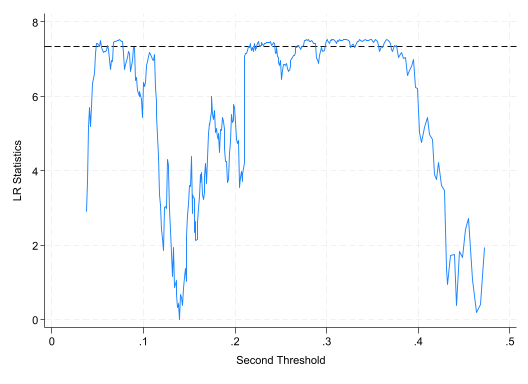

In [52]:
  *-第二个门槛值的 LR 图形	
   cap graph drop LR22	 
   _matplot e(LR22), columns(1 2) yline(7.35, lpattern(dash))  ///
     connect(direct) msize(small) mlabp(0) mlabs(zero)         ///
     ytitle("LR Statistics") xtitle("Second Threshold")        ///
	 recast(line) name(LR22) 
   graph export "$Out/Hansen_Fig02.png", replace //保存图片		 
   


In [ ]:
  *-第三个门槛值的 LR 图形 (Note: 估计完三重门槛模型后才有)	
      cap graph drop LR3	 
   _matplot e(LR3), columns(1 2) yline(7.35, lpattern(dash))   ///
     connect(direct) msize(small) mlabp(0) mlabs(zero)         ///
     ytitle("LR Statistics") xtitle("Third Threshold")         ///
	 recast(line) name(LR3) 
   graph export "$Out/Hansen_Fig03.png", replace //保存图片

**几点说明**：

1. 当样本数较大时，需要慎重设定 `xthreg` 命令中的 `trim()` 选项，以保证每个区间内都有较多的样本可参与估计，
  否则搜索出的门槛值将位于两端；同时，可以通过改变该选项中的数值，来检验结果的稳健性；
2. 在初步分析过程中，可以不设定 `bs()` 选项，以便节省时间，等模型设定稳定后，再设定该选项以便检验门槛效应
3. 对于准备投稿的论文，一定要先设定 `set seed #`，即种子值，如 `set seed 123`。这才能保证结果可重现。
4. 门槛变量也可以出现在解释变量中，即 `rx()` 和 `qx()` 选项中可以是相同的变量。例如，`rx(age)` 和 `qx(age)`。
  
虽然从理论上来讲可能存在多个门槛值，但多数应用中以一个或两个门槛值为主。

> Notes: 
>
> - 一个门槛值模型已经足够捕捉大部分的非线性关系，比如，`V 型`，`L 型` 等等；
> - 若是模型中包含两个门槛值，样本就会被分为三个区间，能够捕捉的非线性关系也更为多样化，比如，`U 型`，`S 型` 等等。

由于实证分析中总会衡量偏误、抽样偏差、遗漏变量偏误等问题。如果单靠数据驱动和假设检验来确定门槛模型，必然存在很大的不确定性。因此，在估计和检验之前，一定要充分讨论问题背景，结合相关理论和文献提出研究假设，以及可能的门槛变量和门槛个数，并尽可能细致地讨论他们的潜在经济含义。 


## 案例 2：Du et al. (2021) - 环境规制与绿色创新

在这案例中，我们使用 Du et al. (2021) 文中的数据来估计面板门槛模型，研究环境规制 ($X$) 对城市绿色创新 ($Y$) 的影响。二者的关系受到经济发展水平 ($Z$) 的调节。

> Du, K., Cheng, Y., & Yao, X. (2021). Environmental regulation, green technology innovation, and industrial structure upgrading: The road to the green transformation of Chinese cities. **Energy Economics**, 98, 105247. [Link](https://doi.org/10.1016/j.eneco.2021.105247) (rep), [PDF](http://sci-hub.ren/10.1016/j.eneco.2021.105247), [-Replication-](https://ars.els-cdn.com/content/image/1-s2.0-S0140988321001523-mmc1.zip), [Google](<https://scholar.google.com/scholar?q=Environmental regulation, green technology innovation, and industrial structure upgrading: The road to the green transformation of Chinese cities>). 

该文研究了环境规制 ($Z$) 对城市绿色转型 ($Y$) 的影响，调节变量为城市人均 GDP ($U$)。

$$
Y_{it}=\gamma\left(U_{i t-1}\right) Z_{i t-1}+\beta^{\prime} X_{i t-1}+\delta_i+\mu_{it} \tag{13}
$$

- $Y_{it}$：下列两个变量之一：
    - **InGTI**：“绿色技术创新” 或 **InIS**：“产业结构升级”
- $Z_{it-1}$：第 $i$ 个城市在 $t-1$ 时刻的环境管制水平 (**ER**)
- $U_{it-1}$：经济发展水平，用人均 GDP 的对数衡量 (**lnGDP**)

In [1]:
clear all

use "https://github.com/lianxhcn/data/raw/refs/heads/main/stata/Du2021EE_ERdata.dta", clear

est clear
eststo clear



Running D:\stata19/profile.do ...


(Du et al. (2021, EE) https://doi.org/10.1016/j.eneco.2021.105247)


In [2]:
xtset 
codebook cityno year gti er gdp lngti lngdp, compact
des gti er gdp


Panel variable: cityno (strongly balanced)
 Time variable: year, 2002 to 2015
         Delta: 1 unit

Variable    Obs Unique      Mean       Min       Max  Label
-------------------------------------------------------------------------------
cityno     1470    105        53         1       105  City ID (105 environme...
year       1470     14    2008.5      2002      2015  Year
gti        1470    549  382.1381         0     13712  Green technology paten...
er         1470   1460  .0829945   .023842   .446886  ER: environmental regu...
gdp        1470   1456  29835.04   3347.96    127586  Real GDP per capita (2...
lngti      1470    548  4.322056         0  9.526027  lnGTI = ln(gti)
lngdp      1470   1456  10.08827  8.116106  11.75655  lnGDP = ln(gdp)
-------------------------------------------------------------------------------

Variable      Storage   Display    Value
    name         type    format    label      Variable label
-------------------------------------------------------

这里使用 Hansen (1999) 提出的面板门槛模型来估计上述变系数面板数据模型。Stata 中可以使用 `xthreg` 命令来实现。

对应于 Du et al. (2021) 的问题背景，我们可以将单重面板门槛模型设定如下：

$$Y_{it} = \alpha_i 
        + Z_{it}^{\prime} {\gamma}_1 \cdot I\left(U_{it} \leq \lambda\right) 
        + Z_{it}^{\prime} {\gamma}_2 \cdot I\left(U_{it}>\lambda\right)
        + X_{it}\beta
        +\varepsilon_{it} \tag{1}
$$

双重门槛模型包含两个门槛值：$\lambda_1$ 和 $\lambda_2$，设定如下：

$$
Y_{it} = \alpha_i 
        + Z_{it}^{\prime} {\gamma}_1 \cdot I\left(U_{it} \leq \lambda_1\right) 
        + Z_{it}^{\prime} {\gamma}_2 \cdot I\left(\lambda_1 < U_{it} \ge \lambda_2\right)
        + Z_{it}^{\prime} {\gamma}_3 \cdot I\left(U_{it} < \lambda_2\right)
        + X_{it}\beta
        +\varepsilon_{it} \tag{1}
$$




In [3]:
set seed 12345
local xlist "lnrd lnpop lnhc lninv lnfdi"
xthreg lngti `xlist', ///
       rx(er) qx(lngdp) ///
       thnum(2) trim(0.10 0.10) bs(500 500) ///
       nobslog //noreg

est store Du2021_2thres

Estimating  the  threshold  parameters:   1st ......  2nd ......  Done
Boostrapping for threshold effect test:   1st ......  2nd ......  Done

Threshold estimator (level = 95):
-----------------------------------------------------
     model |    Threshold         Lower         Upper
-----------+-----------------------------------------
      Th-1 |      10.3718       10.3260       10.3801
     Th-21 |      10.3718       10.3260       10.3801
     Th-22 |       9.3856        9.3739        9.3911
-----------------------------------------------------

Threshold effect test (bootstrap = 500 500):
-------------------------------------------------------------------------------
 Threshold |       RSS        MSE      Fstat    Prob   Crit10    Crit5    Crit1
-----------+-------------------------------------------------------------------
    Single |  386.0885     0.2652      62.21  0.0040  32.6886  38.7691  54.4945
    Double |  364.9414     0.2506      84.37  0.0000  21.2641  23.9729  33.6676

In [27]:
*-列表呈现估计结果
esttab Du2021_2thres, nogap


----------------------------
                      (1)   
                    lngti   
----------------------------
lnrd                0.900***
                  (17.17)   
lnpop               2.220***
                  (11.82)   
lnhc                0.650***
                  (10.71)   
lninv               0.593***
                   (8.94)   
lnfdi             -0.0816***
                  (-3.76)   
0._cat#c.er        -5.941***
                  (-5.52)   
1._cat#c.er         1.572*  
                   (2.22)   
2._cat#c.er         5.830***
                   (8.38)   
_cons              -14.48***
                 (-12.75)   
----------------------------
N                    1470   
----------------------------
t statistics in parentheses
* p<0.05, ** p<0.01, *** p<0.001


In [ ]:
eret list   // 查看返回值，需要执行时去掉前面的 * 即可

In [4]:
mat lambda = e(Thrss)  //存储门槛值的矩阵
mat list lambda


lambda[3,5]
       Threshold        RSS   Location      Lower      Upper
 Th-1  10.371793  386.08846        234  10.326015  10.380104
Th-21  10.371793  364.94139        178  10.326015  10.380104
Th-22  9.3856125  364.94139         26  9.3738585  9.3910856


In [5]:
*-记录门槛值 λ1 和 λ2
local lambda_1 = lambda[3,1]   // Th-22
local lambda_2 = lambda[2,1]   // Th-21
global lambda_1: dis %3.2f `lambda_1'  // 保留两位小数存储
global lambda_2: dis %3.2f `lambda_2'  // 保留两位小数存储

dis _skip(20) "门槛值：λ1 = ${lambda_1} , λ2 = ${lambda_2}"

                    门槛值：λ1 = 9.39 , λ2 = 10.37


In [6]:
*-记录系数估计值 γ1, γ2, γ3

global gamma_1: dis %3.2f _b[0._cat#c.er]
global gamma_2: dis %3.2f _b[1._cat#c.er]
global gamma_3: dis %3.2f _b[2._cat#c.er]

dis _skip(20) "系数估计值：γ1 = ${gamma_1} , γ2 = ${gamma_2} , γ3 = ${gamma_3}"

                    系数估计值：γ1 = -5.94 , γ2 = 1.57 , γ3 = 5.83


为了更直观地理解面板门槛模型的系数含义，下面对三个区间的估计系数进行可视化展示。

我们先绘制面板门槛模型的估计结果，步骤如下：

1. 提取面板门槛模型的估计结果，包括边际效应的点估计和置信区间。边际效应  ($\hat{\gamma}_1, \hat{\gamma}_2, \hat{\gamma}_3$) 在三个区间内的估计值均为常数；置信区间也为常数，计算公式为 $\hat{\gamma}_j \pm 1.96 \times SE(\hat{\gamma}_j)$，其中 $j=1,2,3$。
2. 绘制边际效应随调节变量变化的图形。横轴为调节变量 $U$，纵轴为边际效应 $\gamma(U)$。在每个区间内绘制水平线表示边际效应的点估计，并用阴影区域表示置信区间。此外，在图中标注门槛值 $\lambda_1$ 和 $\lambda_2$ 以显示不同区间的分界点。

Unable to drop gamma* gamma*_lb gamma*_ub


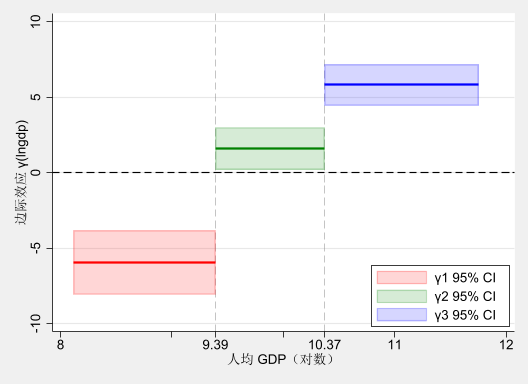

In [7]:
*-三个区间的系数估计值
dropvars gamma* gamma*_lb gamma*_ub

local qui "quietly"
`qui' gen gamma1 = _b[0._cat#c.er] if inrange(lngdp, ., $lambda_1)
`qui' gen gamma2 = _b[1._cat#c.er] if inrange(lngdp, $lambda_1, $lambda_2)
`qui' gen gamma3 = _b[2._cat#c.er] if inrange(lngdp, $lambda_2, .)

*-计算置信区间 = 估计值 ± 1.96*标准误
`qui' gen gamma1_lb = gamma1 - 1.96 * _se[0._cat#c.er]
`qui' gen gamma1_ub = gamma1 + 1.96 * _se[0._cat#c.er]
`qui' gen gamma2_lb = gamma2 - 1.96 * _se[1._cat#c.er]
`qui' gen gamma2_ub = gamma2 + 1.96 * _se[1._cat#c.er]
`qui' gen gamma3_lb = gamma3 - 1.96 * _se[2._cat#c.er]
`qui' gen gamma3_ub = gamma3 + 1.96 * _se[2._cat#c.er]

*----- 绘图
twoway (rarea gamma1_lb gamma1_ub lngdp, color(red%20)   sort) ///
       (rarea gamma2_lb gamma2_ub lngdp, color(green%20) sort) ///
       (rarea gamma3_lb gamma3_ub lngdp, color(blue%20)  sort) ///
       (line  gamma1 lngdp, lc(red)   lp(solid) lw(*2) sort) ///
       (line  gamma2 lngdp, lc(green) lp(solid) lw(*2) sort) ///
       (line  gamma3 lngdp, lc(blue)  lp(solid) lw(*2) sort) ///
       , ///
       yline(0, lc(black) lp(dash)) ///
       xtitle("人均 GDP（对数）") ///
       ytitle("边际效应 γ(lngdp)") ///
       xline(${lambda_1} ${lambda_2}, lc(gray) lp(dash) lw(*0.4)) ///
       xlabel(8 9 " " ${lambda_1} 10 " " ${lambda_2} 11 12) ///
       legend(order(1 "γ1 95% CI" 2 "γ2 95% CI" 3 "γ3 95% CI") ///
              ring(0) pos(5) c(1)) ///
       scheme(s2mono)

该图显示了环境规制对绿色技术创新的边际效应随经济发展水平的变化情况。可以看出：

- 当人均 GDP 较低时 ($\ln GDP < \hat{\lambda}_1 (9.39)$)，环境规制对绿色技术创新的边际效应为负且显著，说明对于经济发展水平较低的城市或在经济发展初期，环境规制非但不会促进绿色技术创新，反而可能抑制绿色技术创新。
- 当人均 GDP 处于中等水平时 ($\hat{\lambda}_1 < \ln GDP \le \hat{\lambda}_2 (10.38)$)，环境规制对绿色技术创新的边际效应转为正值，但不显著，说明在这一阶段，环境规制对绿色技术创新的促进作用尚不明显。
- 当人均 GDP 较高时 ($\ln GDP > \hat{\lambda}_2$)，环境规制对绿色技术创新的边际效应显著为正，表明在经济发展水平较高的城市，环境规制能够有效促进绿色技术创新。

一个直观的解释是，随着经济的发展，城市具备了更强的资源和能力来应对环境规制带来的挑战，从而能够将环境规制转化为推动绿色技术创新的动力。这一发现对于政策制定者具有重要意义，表明在制定环境政策时，应考虑城市的经济发展水平，以实现环境保护与经济增长的双赢目标。

### 补充：门槛值的 LR 检验图示

这里给出两个门槛值的 LR 图形，以便读者理解门槛值的确定过程。


e(Thrss)[3,5]
       Threshold        RSS   Location      Lower      Upper
 Th-1  10.371793  386.08846        234  10.326015  10.380104
Th-21  10.371793  364.94139        178  10.326015  10.380104
Th-22  9.3856125  364.94139         26  9.3738585  9.3910856


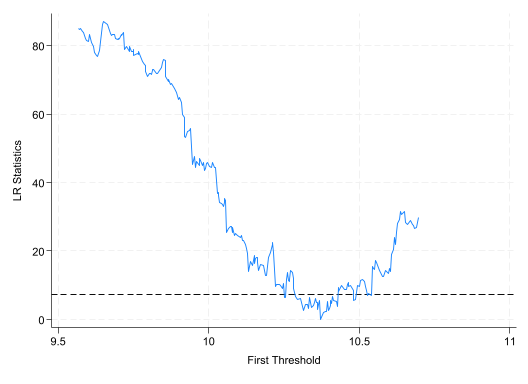

In [8]:
*-提取门槛值, 后续回归分析中会使用
  //ereturn list
    mat list e(Thrss)
    mat s = e(Thrss)  //记录门槛值的矩阵
    global q1 = s[2,1]      //保存估计出的第一个门槛值,以备后用 
    global q2 = s[3,1]      //保存第二个门槛值 		
		
*-Graphing
   
  *-第一个门槛值的 LR 图形
   cap graph drop LR21
   _matplot e(LR21), columns(1 2) yline(7.35, lpattern(dash))  ///
     connect(direct) msize(small) mlabp(0) mlabs(zero)         ///
     ytitle("LR Statistics") xtitle("First Threshold")         ///
	 recast(line) name(LR21) 
   qui graph export "$Out/Du-2021-xthreg-Fig01.png", replace //保存图片
   


(file /Du-2021-xthreg-Fig02.png not found)
file /Du-2021-xthreg-Fig02.png written in PNG format


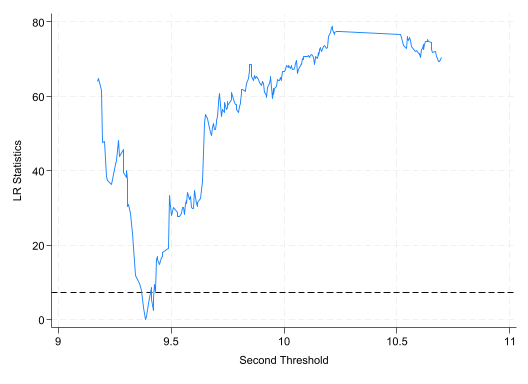

In [9]:
  *-第二个门槛值的 LR 图形	
   cap graph drop LR22	 
   _matplot e(LR22), columns(1 2) yline(7.35, lpattern(dash))  ///
     connect(direct) msize(small) mlabp(0) mlabs(zero)         ///
     ytitle("LR Statistics") xtitle("Second Threshold")        ///
	 recast(line) name(LR22) 
   graph export "$Out/Du-2021-xthreg-Fig02.png", replace //保存图片		 

### 稳健性检验

实证研究中常见的稳健性检验包括：

1. **更换门槛变量**：尝试其他可能的门槛变量
2. **调整修剪比例**：`trim(0.10)` 或 `trim(0.20)`
3. **子样本分析**：按行业、规模等分组
4. **控制变量**：增加更多控制变量
5. **内生性处理**：使用工具变量（需要动态面板门槛模型）

## 参考文献

- **核心文献**
  - Hansen, B. E. (1999). Threshold effects in non-dynamic panels: Estimation, testing, and inference. *Journal of Econometrics*, 93(2), 345–368. [Link](https://doi.org/10.1016/S0304-4076(99)00025-1), [PDF](http://sci-hub.ren/10.1016/S0304-4076(99)00025-1), [Google Scholar](<https://scholar.google.com/scholar?q=Threshold+effects+in+non-dynamic+panels>).
  - Wang, Q. (2015). Fixed-effect panel threshold model using Stata. *The Stata Journal*, 15(1), 121–134. [Link](https://doi.org/10.1177/1536867X1501500108), [PDF](https://journals.sagepub.com/doi/pdf/10.1177/1536867X1501500108), [Google Scholar](https://scholar.google.com/scholar?q=Fixed-Effect+Panel+Threshold+Model+using+Stata).
  - Fazzari, S. M., Hubbard, R. G., & Petersen, B. C. (1988). Financing Constraints and Corporate Investment. *Brookings Papers on Economic Activity*, 1988(1), 141–206. [Link](https://doi.org/10.2307/2534426), [PDF](http://sci-hub.ren/10.2307/2534426), [Google](<https://scholar.google.com/scholar?q=Financing Constraints and Corporate Investment>). 
  - Du , K., Cheng, Y., & Yao, X. (2021). Environmental regulation, green technology innovation, and industrial structure upgrading: The road to the green transformation of Chinese cities. *Energy Economics*, 98, 105247. [Link](https://doi.org/10.1016/j.eneco.2021.105247), [PDF](<http://sci-hub.ren/10.1016/j.eneco.2021.105247), [Google Scholar](https://scholar.google.com/scholar?q=Environmental+regulation,+green+technology+innovation,+and+industrial+structure+upgrading:+The+road+to+the+green+transformation+of+Chinese+cities>).

- **理论基础和估计方法**
  - Chan, K. S. (1993). Consistency and limiting distribution of the least squares estimator of a threshold autoregressive model. *The Annals of Statistics*, 21(1), 520–533. [Link](https://doi.org/10.1214/aos/1176349040), [Google Scholar](https://scholar.google.com/scholar?q=Chan+1993+threshold+autoregressive).
  - Davies, R. B. (1987). Hypothesis testing when a nuisance parameter is present only under the alternative. *Biometrika*, 74(1), 33–43. [Link](https://doi.org/10.1093/biomet/74.1.33).
  - Bai, J. (1997). Estimation of a change point in multiple regression models. *Review of Economics and Statistics*, 79(4), 551–563. [Link](https://doi.org/10.1162/003465397557132).
  - Bai, J., & Perron, P. (1998). Estimating and testing linear models with multiple structural changes. *Econometrica*, 66(1), 47–78. [Link](https://doi.org/10.2307/2998540).
  - Chong, T. T. L. (1994). Consistency of change-point estimators. *Econometric Theory*, 10(1), 28–51. [Link](https://doi.org/10.1017/S0266466600008215).

- **应用文献**
  - Adam, C. S., & Bevan, D. L. (2005). Fiscal deficits and growth in developing countries. *Journal of Public Economics*, 89(4), 571–597. [Link](https://doi.org/10.1016/j.jpubeco.2004.02.006).
  - Cecchetti, S. G., Mohanty, M. S., & Zampolli, F. (2011). The real effects of debt. BIS Working Papers No. 352. [PDF](https://www.bis.org/publ/work352.pdf).
  - Fazzari, S. M., Hubbard, R. G., & Petersen, B. C. (1988). Financing constraints and corporate investment. *Brookings Papers on Economic Activity*, 1988(1), 141–206. [PDF](http://people.stern.nyu.edu/eofek/PhD/papers/FHP_Financing_BPEA.pdf).
  - Girma, S. (2005). Absorptive capacity and productivity spillovers from FDI: A threshold regression analysis. *Oxford Bulletin of Economics and Statistics*, 67(3), 281–306. [Link](https://doi.org/10.1111/j.1468-0084.2005.00120.x).
  - Khan, M. S., & Senhadji, A. S. (2001). Threshold effects in the relationship between inflation and growth. *IMF Staff Papers*, 48(1), 1–21. [Link](https://doi.org/10.2307/3872479).
  - Kremer, S., Bick, A., & Nautz, D. (2013). Inflation and growth: New evidence from a dynamic panel threshold analysis. *Empirical Economics*, 44(2), 861–878. [Link](https://doi.org/10.1007/s00181-012-0553-9).

- **中文文献**
  - 连玉君, 程建 (2006). 不同成长机会下资本结构与经营绩效之关系研究. *当代经济科学*, (2), 1–9.
  - 胡援成, 肖德勇 (2007). 经济发展门槛与自然资源诅咒——基于我国省际层面的面板数据实证研究. *管理世界*, (4), 15–23.
  - 李平, 许家云 (2011). 国际智力回流的技术扩散效应研究——基于中国地区差异及门槛回归的实证分析. *经济学(季刊)*, (3), 1181–1202.
  - 李梅, 柳士昌 (2012). 对外直接投资逆向技术溢出的地区差异和门槛效应. *管理世界*, (1), 21–32.
  - 王永水, 朱平芳 (2016). 中国经济增长中的人力资本门槛效应研究. *统计研究*, 33(1), 13–19.
  - 郭桂霞, 彭艳 (2016). 我国资本账户开放的门槛效应研究. *金融研究*, (3), 42–58.

